In [1]:
from hydra import compose, initialize
from data import load_datamodule

import os
from pathlib import Path
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())

with initialize(config_path="../configs"):
    cfg = compose(config_name="train")


dm = load_datamodule(cfg)
dm.setup()
dl = dm.train_dataloader()

/home/giacomo/repos/dream-machines/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_1555062/2928430716.py:8: Hydra14MigrationWarning: 
The version_base parameter is not specified.
Hydra will assume defaults for version 1.1.
Hydra 1.4 will remove this compatibility behavior.
Before upgrading to Hydra 1.4, set version_base="1.3" and test your application.
See https://hydra.cc/docs/upgrades/1.3_to_1.4/prepare_for_1_4/ for preparation instructions.
  with initialize(config_path="../configs"):


In [2]:
batch = next(iter(dl))

X, y = batch

In [4]:
from model import hl_gauss_target
import math
import torch

n_bins = 201
sigma_ratio = 0.75
bins = y
# (B,) bin indices -> (B, n_bins) mass of a Gaussian centred on each bin, renormalised to the bins' support;
# in bin units: bin k spans [k - 0.5, k + 0.5] and sigma = sigma_ratio
edges = torch.arange(n_bins + 1, device=bins.device) - 0.5
cdf = torch.special.erf((edges - bins[:, None]) / (math.sqrt(2) * sigma_ratio))
(cdf[:, 1:] - cdf[:, :-1]) / (cdf[:, -1:] - cdf[:, :1])

tensor([[0.6622, 0.3073, 0.0299,  ..., 0.0000, 0.0000, 0.0000],
        [0.6622, 0.3073, 0.0299,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.6622, 0.3073, 0.0299,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.6622, 0.3073, 0.0299,  ..., 0.0000, 0.0000, 0.0000]])

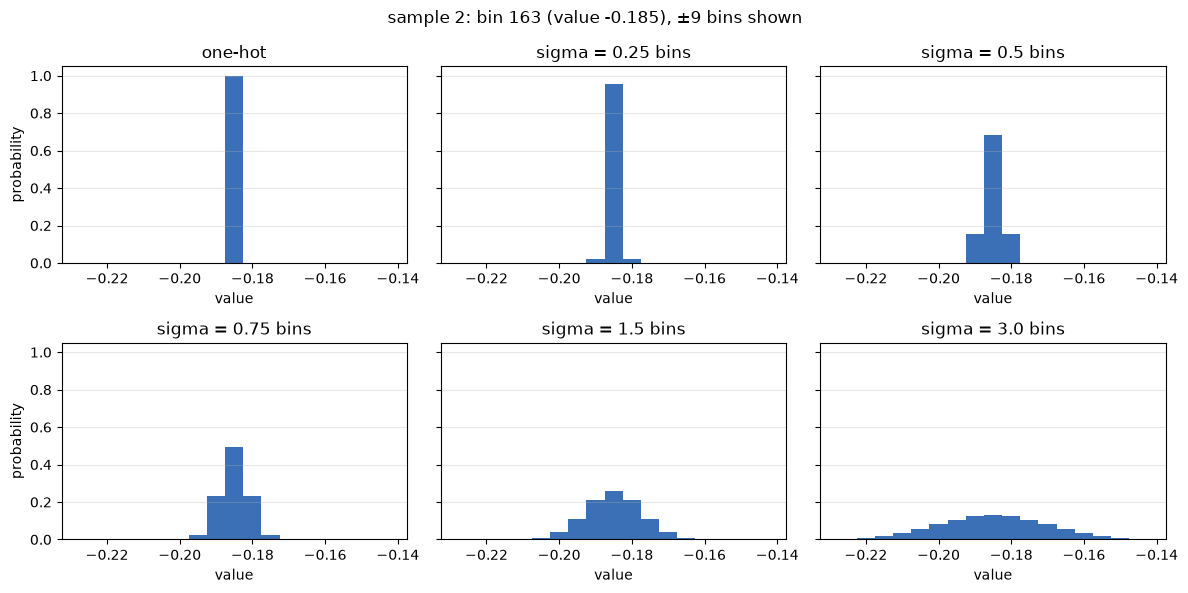

In [13]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

SAMPLE_ID = 2 # index in the batch
SIGMA_RATIOS = [0.25, 0.5, 0.75, 1.5, 3.0]  # in bin widths
ZOOM_BINS = math.ceil(3 * max(SIGMA_RATIOS))  # bins shown on each side of the target bin: 3 sigma
N_COLS = 3

target_bin = y[SAMPLE_ID : SAMPLE_ID + 1]  # (1,)
targets = [("one-hot", F.one_hot(target_bin, n_bins).float()[0])] + [
    (f"sigma = {s} bins", hl_gauss_target(target_bin, n_bins, s)[0]) for s in SIGMA_RATIOS
]
bin_centres = torch.linspace(-1, 0, n_bins)
bin_width = 1 / (n_bins - 1)
centre = bin_centres[target_bin].item()

n_rows = math.ceil(len(targets) / N_COLS)
fig, axes = plt.subplots(
    n_rows, N_COLS, figsize=(4 * N_COLS, 3 * n_rows), sharex=True, sharey=True, squeeze=False
)
for ax, (title, probs) in zip(axes.flat, targets):
    ax.bar(bin_centres, probs, width=bin_width, color="#3b6fb6")
    ax.set_xlim(centre - (ZOOM_BINS + 0.5) * bin_width, centre + (ZOOM_BINS + 0.5) * bin_width)
    ax.set_title(title)
    ax.set_xlabel("value")
    ax.xaxis.set_tick_params(labelbottom=True)  # sharex hides them on all but the last row
    ax.grid(axis="y", alpha=0.3)
for ax in axes.flat[len(targets) :]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("probability")
fig.suptitle(f"sample {SAMPLE_ID}: bin {target_bin.item()} (value {centre:.3f}), ±{ZOOM_BINS} bins shown")
fig.tight_layout()
plt.show()